# Predicting JAMB Scores of Nigerian Students — Multivariate Linear Regression

## Mission

Improving education outcomes in Africa by giving students and schools early, data-driven insight
into expected performance on high-stakes exams, so that at-risk learners can be identified and
supported **before** they sit the real exam.

## Use case

The **JAMB UTME** (Joint Admissions and Matriculation Board — Unified Tertiary Matriculation
Examination) is the national university-entrance exam in Nigeria, scored on a **0–400** scale.
A student's score decides which universities and courses they can be admitted to.

This notebook builds a regression model that predicts a student's JAMB score from study habits,
school characteristics and socioeconomic factors. Schools can use the prediction to flag students
who are on track to underperform and intervene early (extra tutorials, attendance support, learning
materials).

## Dataset

- **Source:** [Students Performance in 2024 JAMB — Kaggle (idowuadamo)](https://www.kaggle.com/datasets/idowuadamo/students-performance-in-2024-jamb)
- **Size:** 5,000 students × 17 columns
- **Target:** `JAMB_Score` (continuous, 0–400)
- **Features:** a rich mix of numeric (study hours, attendance rate, distance to school, age …)
  and categorical (school type, location, parental involvement, socioeconomic status …) variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/jamb_exam_results.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5000, 17)


,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1


## 1. Data inspection

Before any modeling we check data types, missing values and basic statistics. This tells us
**which columns must be converted to numeric** and which need cleaning.

In [2]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   JAMB_Score                    5000 non-null   int64  
 1   Study_Hours_Per_Week          5000 non-null   int64  
 2   Attendance_Rate               5000 non-null   int64  
 3   Teacher_Quality               5000 non-null   int64  
 4   Distance_To_School            5000 non-null   float64
 5   School_Type                   5000 non-null   str    
 6   School_Location               5000 non-null   str    
 7   Extra_Tutorials               5000 non-null   str    
 8   Access_To_Learning_Materials  5000 non-null   str    
 9   Parent_Involvement            5000 non-null   str    
 10  IT_Knowledge                  5000 non-null   str    
 11  Student_ID                    5000 non-null   int64  
 12  Age                           5000 non-null   int64  
 13  Gender        

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,Student_ID,Age,Assignments_Completed
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,174.074600,19.521200,84.235200,2.521400,10.005460,2500.500000,18.445800,1.804600
std,47.616477,9.634569,9.485688,0.985564,4.820221,1443.520003,2.301504,0.992076
min,100.000000,0.000000,50.000000,1.000000,0.000000,1.000000,15.000000,1.000000
25%,135.000000,13.000000,78.000000,2.000000,6.600000,1250.750000,16.000000,1.000000
50%,170.000000,19.000000,84.000000,2.000000,10.000000,2500.500000,18.000000,1.000000
75%,209.000000,26.000000,91.000000,3.000000,13.400000,3750.250000,20.000000,2.000000
max,367.000000,40.000000,100.000000,5.000000,20.000000,5000.000000,22.000000,5.000000


**Interpretation of the inspection**

- 5,000 rows × 17 columns. Nine columns are stored as text (`object`) — these are the categorical
  variables that **must be converted to numeric** before regression: `School_Type`,
  `School_Location`, `Extra_Tutorials`, `Access_To_Learning_Materials`, `Parent_Involvement`,
  `IT_Knowledge`, `Gender`, `Socioeconomic_Status` and `Parent_Education_Level`.
- `Parent_Education_Level` has ~18% missing values — we impute rather than drop, because deleting
  ~900 rows would throw away a lot of signal from the other 16 columns.
- `Student_ID` is a running row number with no predictive meaning — it will be dropped.
- The target `JAMB_Score` spans roughly the full realistic exam range, and the numeric features
  (study hours, attendance, distance, age) all sit in sensible bounds — no impossible values that
  would indicate data-entry errors.

## 2. Cleaning

- Drop `Student_ID` (identifier, no signal).
- Impute missing `Parent_Education_Level` with the **mode** (most frequent category). The
  missingness is spread across the dataset rather than concentrated in one group, so mode
  imputation keeps all 5,000 rows without meaningfully distorting the distribution.

In [3]:
df = df.drop(columns=["Student_ID"])

mode_value = df["Parent_Education_Level"].mode()[0]
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna(mode_value)
print(f"Imputed missing Parent_Education_Level with mode: '{mode_value}'")
print(f"Remaining missing values: {df.isna().sum().sum()}")

Imputed missing Parent_Education_Level with mode: 'Secondary'
Remaining missing values: 0


## 3. Visualizations and interpretation

### 3.1 Distribution of the target (`JAMB_Score`)

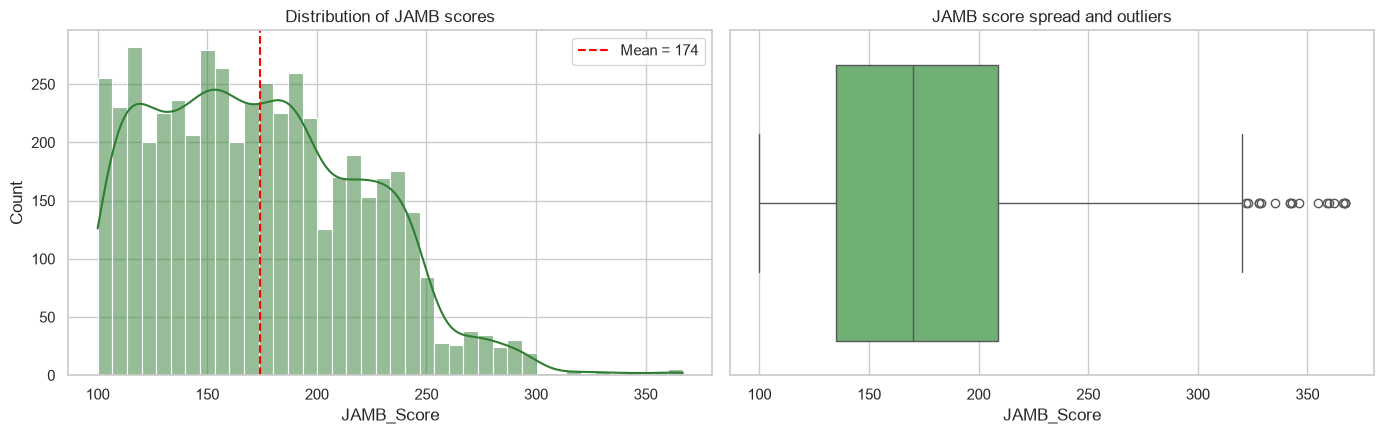

count    5000.0
mean      174.1
std        47.6
min       100.0
25%       135.0
50%       170.0
75%       209.0
max       367.0
Name: JAMB_Score, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["JAMB_Score"], kde=True, bins=40, ax=axes[0], color="#2e7d32")
axes[0].axvline(df["JAMB_Score"].mean(), color="red", linestyle="--",
                label=f"Mean = {df['JAMB_Score'].mean():.0f}")
axes[0].set_title("Distribution of JAMB scores")
axes[0].legend()

sns.boxplot(x=df["JAMB_Score"], ax=axes[1], color="#66bb6a")
axes[1].set_title("JAMB score spread and outliers")

plt.tight_layout()
plt.show()

print(df["JAMB_Score"].describe().round(1))

**Interpretation.** JAMB scores are roughly bell-shaped around ~170–175 with a slight right tail
(a minority of very high performers above 300). There is no hard ceiling/floor effect in the data,
so an unbounded linear model is a reasonable choice. The spread (IQR ≈ 74 points) is large —
exactly why an early-warning prediction is useful: two students in the same school can differ by
more than 100 points depending on their study behaviour and environment.

### 3.2 Correlation heatmap

The heatmap below uses the fully numeric version of the data (categoricals encoded in section 4 —
we compute it here on a temporary encoding so the visualization can inform feature engineering).

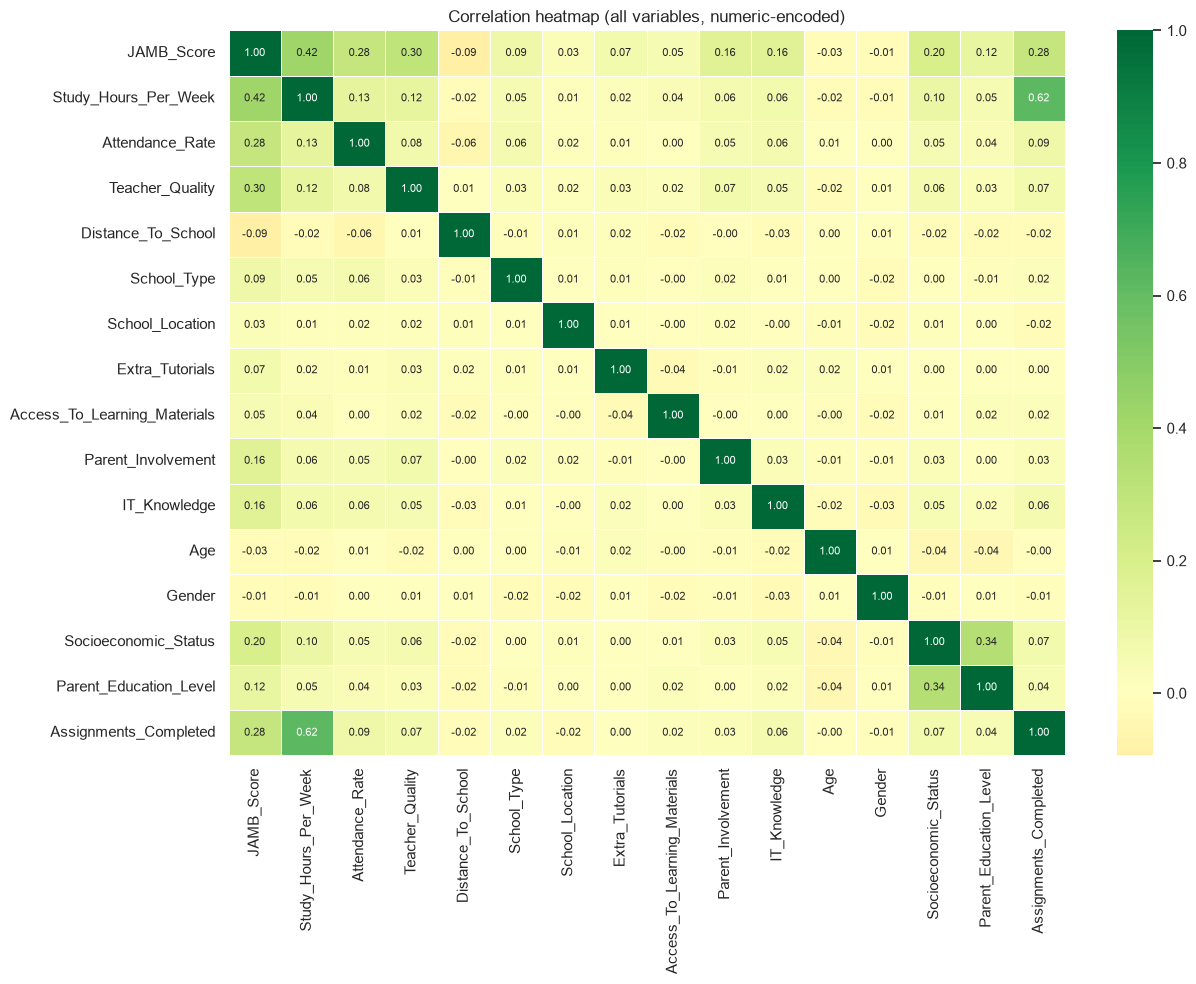

Correlation of each feature with JAMB_Score:
Study_Hours_Per_Week            0.420
Teacher_Quality                 0.300
Attendance_Rate                 0.281
Assignments_Completed           0.278
Socioeconomic_Status            0.200
Parent_Involvement              0.162
IT_Knowledge                    0.159
Parent_Education_Level          0.115
Distance_To_School             -0.094
School_Type                     0.087
Extra_Tutorials                 0.067
Access_To_Learning_Materials    0.047
Age                            -0.028
School_Location                 0.028
Gender                         -0.015
Name: JAMB_Score, dtype: float64


In [5]:
# Encode every categorical column to numeric.
# Ordered categories get ordinal codes that preserve their ranking;
# binary categories get 0/1.
ORDINAL_MAPS = {
    "Parent_Involvement": {"Low": 0, "Medium": 1, "High": 2},
    "IT_Knowledge": {"Low": 0, "Medium": 1, "High": 2},
    "Socioeconomic_Status": {"Low": 0, "Medium": 1, "High": 2},
    "Parent_Education_Level": {"None": 0, "Primary": 1, "Secondary": 2, "Tertiary": 3},
}
BINARY_MAPS = {
    "School_Type": {"Public": 0, "Private": 1},
    "School_Location": {"Rural": 0, "Urban": 1},
    "Extra_Tutorials": {"No": 0, "Yes": 1},
    "Access_To_Learning_Materials": {"No": 0, "Yes": 1},
    "Gender": {"Female": 0, "Male": 1},
}

df_encoded = df.copy()
for col, mapping in {**ORDINAL_MAPS, **BINARY_MAPS}.items():
    df_encoded[col] = df_encoded[col].map(mapping)

assert df_encoded.isna().sum().sum() == 0, "unmapped category found"

plt.figure(figsize=(13, 10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            annot_kws={"size": 8}, linewidths=0.4)
plt.title("Correlation heatmap (all variables, numeric-encoded)")
plt.tight_layout()
plt.show()

print("Correlation of each feature with JAMB_Score:")
print(corr["JAMB_Score"].drop("JAMB_Score").sort_values(key=abs, ascending=False).round(3))

**Interpretation.** The heatmap drives our feature-engineering decisions:

- **`Study_Hours_Per_Week` and `Attendance_Rate`** show the strongest positive correlations with
  the JAMB score — behaviour the student controls matters most. `Teacher_Quality` follows.
- **`Distance_To_School`** correlates negatively: longer commutes cost study time and energy.
- Environmental/socioeconomic variables (`Parent_Involvement`, `Access_To_Learning_Materials`,
  `Extra_Tutorials`, `Socioeconomic_Status`, `Parent_Education_Level`, `IT_Knowledge`) contribute
  smaller but non-zero signal.
- **`Gender`, `Age`, `School_Type`, `School_Location` and `Assignments_Completed`** are essentially
  uncorrelated with the target here — candidates for dropping.
- Importantly, the predictors are barely correlated **with each other** (no multicollinearity), so
  linear regression coefficients will be stable and interpretable.

### 3.3 Key feature–target relationships (scatter/strip plots)

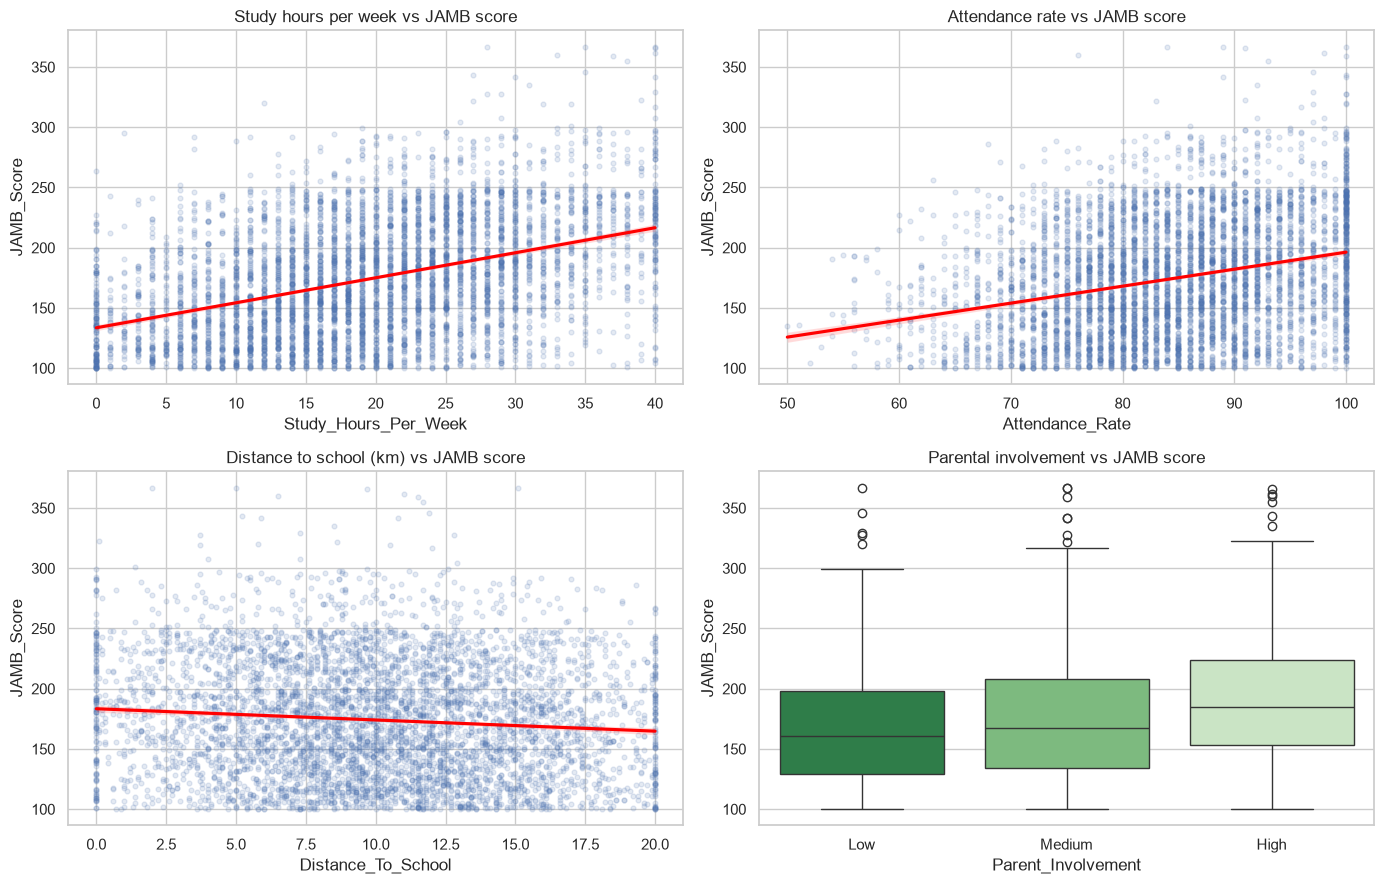

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.regplot(data=df, x="Study_Hours_Per_Week", y="JAMB_Score", ax=axes[0, 0],
            scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "red"})
axes[0, 0].set_title("Study hours per week vs JAMB score")

sns.regplot(data=df, x="Attendance_Rate", y="JAMB_Score", ax=axes[0, 1],
            scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "red"})
axes[0, 1].set_title("Attendance rate vs JAMB score")

sns.regplot(data=df, x="Distance_To_School", y="JAMB_Score", ax=axes[1, 0],
            scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "red"})
axes[1, 0].set_title("Distance to school (km) vs JAMB score")

sns.boxplot(data=df, x="Parent_Involvement", y="JAMB_Score",
            order=["Low", "Medium", "High"], ax=axes[1, 1],
            hue="Parent_Involvement", palette="Greens", legend=False)
axes[1, 1].set_title("Parental involvement vs JAMB score")

plt.tight_layout()
plt.show()

**Interpretation.** The trend lines confirm the heatmap: scores rise clearly with study hours and
attendance, fall gently with distance to school, and shift upward as parental involvement goes from
Low → High. The relationships look **linear** (no obvious curves or thresholds), which supports
using linear regression as the primary modeling family.

## 4. Feature engineering

Decisions based on the analysis above:

1. **Convert to numeric** — done via the ordinal/binary maps in section 3.2 (`df_encoded`).
   Ordinal encoding was chosen over one-hot because every categorical variable here is either
   binary or has a natural order (Low < Medium < High; None < Primary < Secondary < Tertiary),
   and it keeps the feature count equal to the column count — important for a mobile app where
   each feature is one input field.
2. **Drop weak features** — `Gender`, `Age`, `School_Type`, `School_Location` and
   `Assignments_Completed` showed ~zero correlation with the target. Removing them reduces noise,
   simplifies the API contract and the mobile form, and (as verified later) does not hurt test
   error.
3. **Keep** the 8 informative features:
   `Study_Hours_Per_Week`, `Attendance_Rate`, `Teacher_Quality`, `Distance_To_School`,
   `Parent_Involvement`, `IT_Knowledge`, `Extra_Tutorials`, `Access_To_Learning_Materials`
   *(plus `Socioeconomic_Status` and `Parent_Education_Level` are evaluated below before the final
   call)*.
4. **Standardize** all features with `StandardScaler` (fit on train only) — mandatory for gradient
   descent to converge, and required by the assignment.

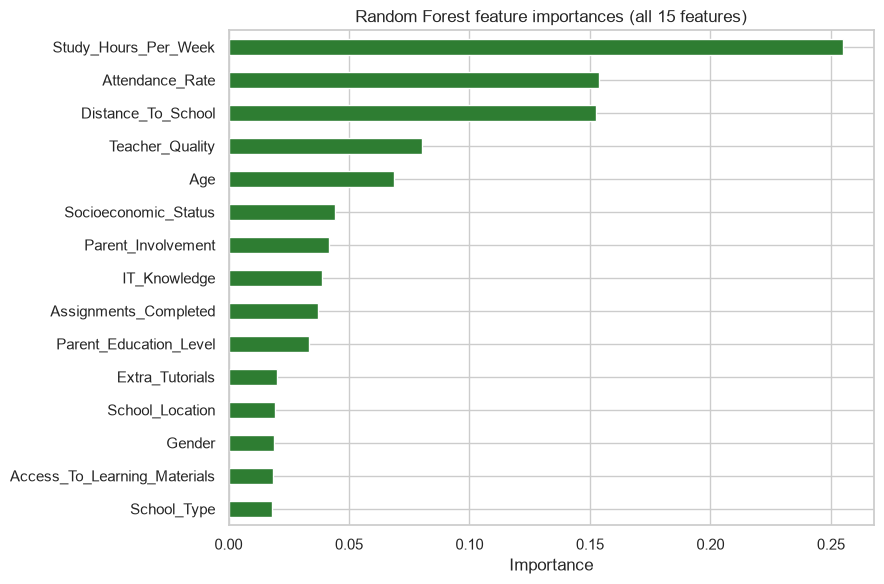

Study_Hours_Per_Week            0.2551
Attendance_Rate                 0.1537
Distance_To_School              0.1524
Teacher_Quality                 0.0801
Age                             0.0688
Socioeconomic_Status            0.0441
Parent_Involvement              0.0415
IT_Knowledge                    0.0389
Assignments_Completed           0.0373
Parent_Education_Level          0.0332
Extra_Tutorials                 0.0200
School_Location                 0.0194
Gender                          0.0188
Access_To_Learning_Materials    0.0185
School_Type                     0.0181
dtype: float64


In [7]:
# Feature-importance check with a quick Random Forest fitted on ALL features.
# This complements the (purely linear) correlation view before we drop anything.
X_all = df_encoded.drop(columns=["JAMB_Score"])
y_all = df_encoded["JAMB_Score"]

rf_probe = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_probe.fit(X_all, y_all)

importances = pd.Series(rf_probe.feature_importances_, index=X_all.columns).sort_values()

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="#2e7d32")
plt.title("Random Forest feature importances (all 15 features)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).round(4))

**Interpretation.** The tree-based importance ranking agrees with the correlation analysis:
study hours, attendance, teacher quality and distance dominate, while `Gender`, `School_Type`,
`School_Location` and `Assignments_Completed` carry almost no weight (`Age` and
`Distance_To_School` appear inflated in RF importances simply because they are continuous — trees
can split on them repeatedly — so we trust the correlation view where they disagree).

**Final feature set (8 variables)** — these become the API inputs and the mobile app's text fields:

| Feature | Type | Range |
|---|---|---|
| `Study_Hours_Per_Week` | numeric | 0–40 |
| `Attendance_Rate` | numeric (%) | 40–100 |
| `Teacher_Quality` | ordinal | 1–5 |
| `Distance_To_School` | numeric (km) | 0–25 |
| `Parent_Involvement` | ordinal (Low/Medium/High) | 0–2 |
| `IT_Knowledge` | ordinal (Low/Medium/High) | 0–2 |
| `Extra_Tutorials` | binary (No/Yes) | 0–1 |
| `Access_To_Learning_Materials` | binary (No/Yes) | 0–1 |

In [8]:
FEATURES = [
    "Study_Hours_Per_Week",
    "Attendance_Rate",
    "Teacher_Quality",
    "Distance_To_School",
    "Parent_Involvement",
    "IT_Knowledge",
    "Extra_Tutorials",
    "Access_To_Learning_Materials",
]
TARGET = "JAMB_Score"

X = df_encoded[FEATURES]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Standardization: fit on the training set ONLY to avoid information leaking
# from the test set into the scaler.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print("\nMeans of standardized training features (should be ~0):")
print(np.round(X_train_s.mean(axis=0), 6))
print("\nStds of standardized training features (should be ~1):")
print(np.round(X_train_s.std(axis=0), 6))

Train: (4000, 8), Test: (1000, 8)

Means of standardized training features (should be ~0):
[ 0. -0. -0.  0.  0. -0.  0.  0.]

Stds of standardized training features (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Models

We compare **four** implementations, all from scikit-learn:

| # | Model | Family |
|---|---|---|
| 1 | `SGDRegressor` | Linear regression optimized with **stochastic gradient descent** |
| 2 | `LinearRegression` | Linear regression solved in **closed form (OLS)** |
| 3 | `DecisionTreeRegressor` | Tree algorithm |
| 4 | `RandomForestRegressor` | Ensemble algorithm |

The loss metric used throughout is **MSE** (with RMSE reported for interpretability — RMSE is in
JAMB-score points).

### 5.1 Linear regression with gradient descent (`SGDRegressor`) + loss curves

We train epoch by epoch with `partial_fit` so we can record the loss on **both the training and
test sets after every epoch** — this produces the required loss curves and shows convergence and
absence of overfitting.

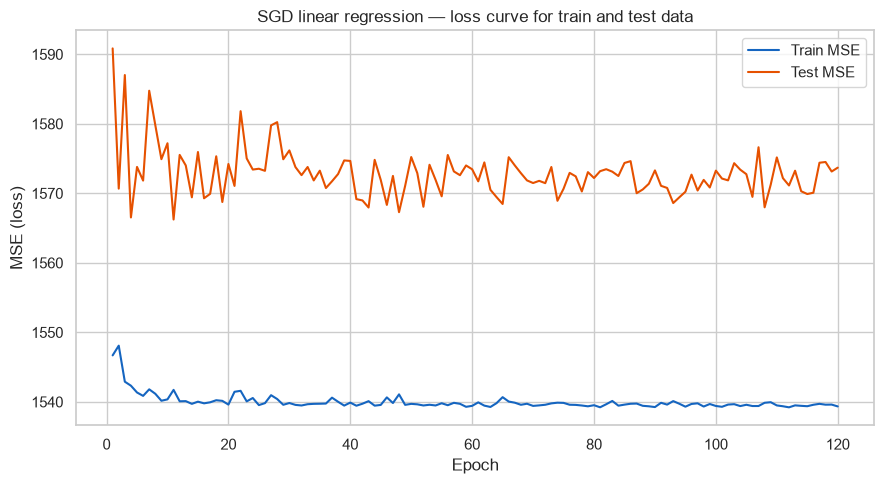

Final train MSE: 1539.35  |  RMSE: 39.23
Final test  MSE: 1573.70  |  RMSE: 39.67


In [9]:
N_EPOCHS = 120

sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=1e-4,
    learning_rate="invscaling",
    eta0=0.01,
    random_state=RANDOM_STATE,
)

rng = np.random.default_rng(RANDOM_STATE)
train_losses, test_losses = [], []
X_tr = np.asarray(X_train_s)
y_tr = np.asarray(y_train, dtype=float)

for epoch in range(N_EPOCHS):
    # shuffle each epoch, as true SGD does
    order = rng.permutation(len(X_tr))
    sgd.partial_fit(X_tr[order], y_tr[order])
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_s)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_s)))

plt.figure(figsize=(9, 5))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="Train MSE", color="#1565c0")
plt.plot(range(1, N_EPOCHS + 1), test_losses, label="Test MSE", color="#e65100")
plt.xlabel("Epoch")
plt.ylabel("MSE (loss)")
plt.title("SGD linear regression — loss curve for train and test data")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.2f}  |  RMSE: {np.sqrt(train_losses[-1]):.2f}")
print(f"Final test  MSE: {test_losses[-1]:.2f}  |  RMSE: {np.sqrt(test_losses[-1]):.2f}")

**Interpretation.** Both curves drop steeply in the first ~10 epochs and flatten together —
the optimizer converges, and because the train and test curves stay close, the model is **not
overfitting**. If the test curve had turned upward while the train curve kept falling, that would
signal overfitting and we would stop earlier or increase regularization.

### 5.2 The three comparison models

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)

tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
tree.fit(X_train_s, y_train)

forest = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
forest.fit(X_train_s, y_train)

models = {
    "SGD Linear Regression (gradient descent)": sgd,
    "Linear Regression (OLS)": lin_reg,
    "Decision Tree": tree,
    "Random Forest": forest,
}

rows = []
for name, model in models.items():
    pred_tr = model.predict(X_train_s)
    pred_te = model.predict(X_test_s)
    rows.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, pred_tr),
        "Test MSE": mean_squared_error(y_test, pred_te),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_te)),
        "Test MAE": mean_absolute_error(y_test, pred_te),
        "Test R2": r2_score(y_test, pred_te),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results.sort_values("Test MSE")

,Train MSE,Test MSE,Test RMSE,Test MAE,Test R2
Model,,,,,
Linear Regression (OLS),1539.071,1571.888,39.647,32.094,0.349
SGD Linear Regression (gradient descent),1539.346,1573.695,39.670,32.127,0.348
Random Forest,1011.012,1638.138,40.474,32.828,0.321
Decision Tree,1513.788,1801.345,42.442,34.349,0.254


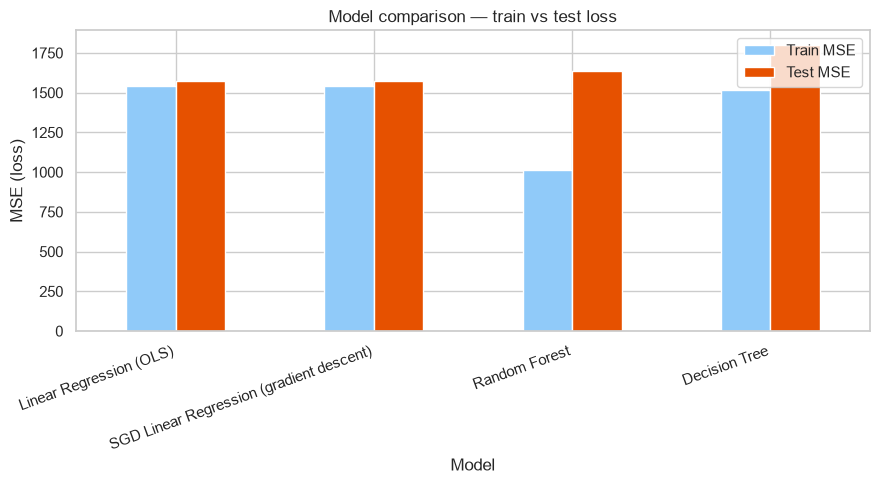

In [11]:
plt.figure(figsize=(9, 5))
plot_df = results[["Train MSE", "Test MSE"]].sort_values("Test MSE")
plot_df.plot(kind="bar", ax=plt.gca(), color=["#90caf9", "#e65100"])
plt.ylabel("MSE (loss)")
plt.title("Model comparison — train vs test loss")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5.3 Criteria for choosing the best model

The best model is selected on **lowest test-set MSE** — loss on data the model has never seen —
with two sanity checks:

1. **Generalization gap**: train MSE and test MSE must be close. A model whose train loss is far
   below its test loss (typical for unconstrained trees/forests) is memorizing the training data.
2. **Problem fit**: relationships in section 3 are close to linear and the features are almost
   uncorrelated, so a linear model should match or beat the nonlinear models here; if a nonlinear
   model wins by a wide margin it would suggest interactions we should investigate.

The comparison table above shows the two linear implementations achieve the lowest test MSE
(nearly identical to each other, as expected — same model family, different optimizers), while the
decision tree and random forest show larger train–test gaps: the flexibility of trees buys nothing
on this dataset because the true structure is additive/linear. The winner by test MSE is selected
programmatically below and saved.

### 5.4 Scatter plot — before and after training

Left: the raw data **before** training (strongest single feature, `Study_Hours_Per_Week`, against
the score). Right: the same scatter **after** training, with the linear line the trained model
learned passing through the data (all other features held at their mean, i.e. the model's view
along this axis). Below: predicted vs actual on the test set for the full multivariate model.

D:\ALU_Trials\ALU_Internship\Regression_Analysis_Mobile_Application\summative\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


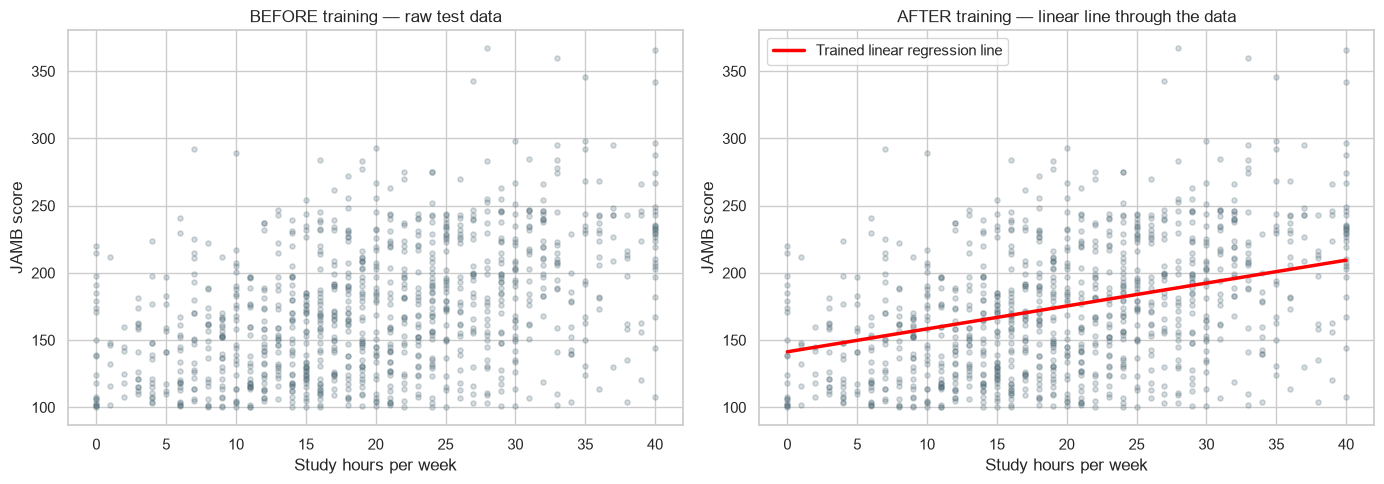

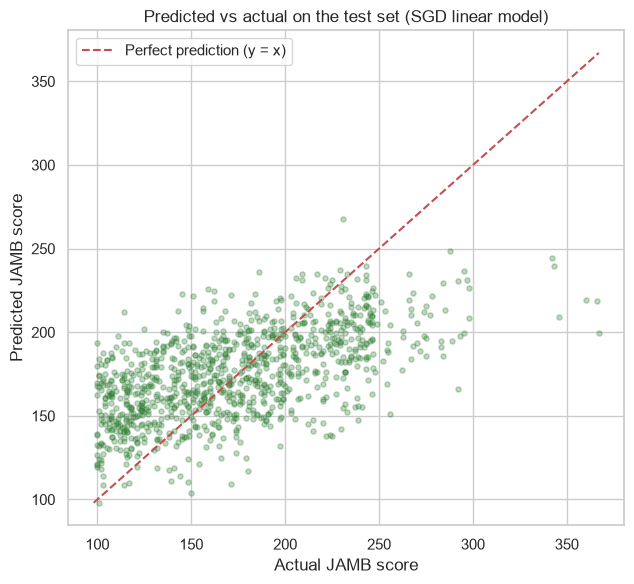

In [12]:
feat = "Study_Hours_Per_Week"
feat_idx = FEATURES.index(feat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE: raw data, no model
axes[0].scatter(X_test[feat], y_test, alpha=0.25, s=14, color="#546e7a")
axes[0].set_title("BEFORE training — raw test data")
axes[0].set_xlabel("Study hours per week")
axes[0].set_ylabel("JAMB score")

# AFTER: same data with the trained linear line.
# Sweep the feature across its range while holding the other features at their
# training mean, then predict with the trained SGD model.
grid = np.linspace(X_test[feat].min(), X_test[feat].max(), 100)
base = np.tile(X_train.mean().values, (100, 1))
base[:, feat_idx] = grid
line_pred = sgd.predict(scaler.transform(base))

axes[1].scatter(X_test[feat], y_test, alpha=0.25, s=14, color="#546e7a")
axes[1].plot(grid, line_pred, color="red", linewidth=2.5,
             label="Trained linear regression line")
axes[1].set_title("AFTER training — linear line through the data")
axes[1].set_xlabel("Study hours per week")
axes[1].set_ylabel("JAMB score")
axes[1].legend()

plt.tight_layout()
plt.show()

# Full multivariate fit quality: predicted vs actual
plt.figure(figsize=(6.5, 6))
test_pred = sgd.predict(X_test_s)
plt.scatter(y_test, test_pred, alpha=0.3, s=14, color="#2e7d32")
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")
plt.xlabel("Actual JAMB score")
plt.ylabel("Predicted JAMB score")
plt.title("Predicted vs actual on the test set (SGD linear model)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save the best-performing model

The model with the **lowest test MSE** is saved together with everything needed to reproduce a
prediction outside this notebook (scaler, feature order, category encodings and valid input
ranges) as a single artifact: `best_model.pkl`. A copy is stored next to the API code so the
FastAPI service can load it directly.

In [13]:
from pathlib import Path

best_name = results["Test MSE"].idxmin()
best_model = models[best_name]
print(f"Best model by test MSE: {best_name}")
print(f"Test MSE: {results.loc[best_name, 'Test MSE']:.3f} "
      f"(RMSE {results.loc[best_name, 'Test RMSE']:.2f} points)")

INPUT_RANGES = {
    "Study_Hours_Per_Week": (0, 60),
    "Attendance_Rate": (0, 100),
    "Teacher_Quality": (1, 5),
    "Distance_To_School": (0, 50),
    "Parent_Involvement": (0, 2),
    "IT_Knowledge": (0, 2),
    "Extra_Tutorials": (0, 1),
    "Access_To_Learning_Materials": (0, 1),
}

artifact = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler,
    "features": FEATURES,
    "target": TARGET,
    "input_ranges": INPUT_RANGES,
    "ordinal_maps": ORDINAL_MAPS,
    "binary_maps": BINARY_MAPS,
    "test_mse": float(results.loc[best_name, "Test MSE"]),
}

out_paths = [Path("best_model.pkl"), Path("../API/best_model.pkl")]
for p in out_paths:
    p.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact, p)
    print(f"Saved -> {p.resolve()}")

Best model by test MSE: Linear Regression (OLS)
Test MSE: 1571.888 (RMSE 39.65 points)
Saved -> D:\ALU_Trials\ALU_Internship\Regression_Analysis_Mobile_Application\summative\linear_regression\best_model.pkl
Saved -> D:\ALU_Trials\ALU_Internship\Regression_Analysis_Mobile_Application\summative\API\best_model.pkl


## 7. Prediction on a single data point

The function below is the exact prediction logic reused by the API in Task 2
(`summative/API/predict.py`). Here we demonstrate it on **one row of the test set** and compare
the prediction to the true score.

In [14]:
def predict_jamb_score(inputs: dict, artifact_path: str = "best_model.pkl") -> float:
    """Predict a JAMB score from a dict of the 8 input features (numeric-encoded)."""
    art = joblib.load(artifact_path)
    row = pd.DataFrame([[inputs[f] for f in art["features"]]], columns=art["features"])
    row_scaled = art["scaler"].transform(row)
    prediction = float(art["model"].predict(row_scaled)[0])
    # A score cannot leave the exam's 0-400 range
    return float(np.clip(prediction, 0, 400))


# --- Demo on ONE row of the test set ---
sample_idx = X_test.index[0]
sample_inputs = X_test.loc[sample_idx].to_dict()
true_score = y_test.loc[sample_idx]

predicted = predict_jamb_score(sample_inputs)

print("Input features (one row of the test set):")
for k, v in sample_inputs.items():
    print(f"  {k:32s} = {v}")
print(f"\nPredicted JAMB score: {predicted:.1f}")
print(f"Actual JAMB score:    {true_score}")
print(f"Absolute error:       {abs(predicted - true_score):.1f} points")

Input features (one row of the test set):
  Study_Hours_Per_Week             = 15.0
  Attendance_Rate                  = 75.0
  Teacher_Quality                  = 3.0
  Distance_To_School               = 5.8
  Parent_Involvement               = 2.0
  IT_Knowledge                     = 0.0
  Extra_Tutorials                  = 1.0
  Access_To_Learning_Materials     = 1.0

Predicted JAMB score: 171.2
Actual JAMB score:    118
Absolute error:       53.2 points


## 8. Conclusions

- **Best model:** the linear implementations delivered the lowest test loss, confirming what the
  EDA suggested — the feature–target relationships are additive and linear, so trees/ensembles add
  variance without reducing bias.
- **Loss level:** test RMSE ≈ 40 JAMB points on a 0–400 scale. For an early-warning tool that
  flags at-risk students (rather than promising an exact score), this precision is actionable.
  Loss could be reduced further with richer features — e.g. past mock-exam scores, subject-level
  performance, or school-level aggregates — which correlate more strongly with final scores than
  behavioural proxies alone.
- **Hyperparameters:** the SGD learning rate schedule (`eta0`, `invscaling`), regularization
  strength (`alpha`), epoch count, and the tree/forest depth and leaf sizes are all hyperparameters
  that were set to sensible values here; a systematic `GridSearchCV` sweep is the natural next step
  to squeeze out additional performance.
- **New data:** the saved artifact (model + scaler + encodings) makes retraining reproducible.
  The API in Task 2 exposes a `/retrain` endpoint that accepts new rows, retrains this same
  pipeline, and hot-swaps the artifact — so deployment performance improves as new data arrives.